##1. Các thư viện


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

plt.rcParams["figure.figsize"] = (14, 5)

##2. Đọc dữ liệu từ file

In [ ]:
DATA_PATH = '/content/drive/MyDrive/DoAnChuyenNganh/Database/PJME_hourly.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


##3. Kiểm tra nhanh cấu trúc dữ liệu

In [ ]:
print("Shape:", df.shape)
print(df.dtypes)
display(df.head())

Shape: (145366, 2)
Datetime     object
PJME_MW     float64
dtype: object


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


Hình trên cho thấy tập dữ liệu gồm 145.366 quan sát với 2 biến là Datetime và PJME_MW.
Biến PJME_MW có kiểu float64 phù hợp cho dự báo, tuy nhiên Datetime đang ở dạng object nên cần chuyển sang định dạng datetime trước khi huấn luyện mô hình.

##4. Chuẩn hóa dữ liệu

In [ ]:
# Đổi kiểu Datetime
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

# Đổi tên cột theo chuẩn Prophet
data = df.rename(columns={"Datetime": "ds", "PJME_MW": "y"}).copy()

# Làm sạch cơ bản
data["y"] = pd.to_numeric(data["y"], errors="coerce")
data = data.dropna(subset=["ds", "y"]).sort_values("ds").reset_index(drop=True)

print("Date range:", data["ds"].min(), "to", data["ds"].max())
print("Rows:", len(data))
data.head()

Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Rows: 145366


,ds,y
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


##5. Xử lý dữ liệu theo giờ: trùng timestamp và thiếu giờ

In [ ]:
# Gộp các timestamp trùng (lấy mean)
data = data.groupby("ds", as_index=False)["y"].mean().sort_values("ds").reset_index(drop=True)

# Tạo dải giờ đầy đủ
full_range = pd.date_range(data["ds"].min(), data["ds"].max(), freq="h")

# Reindex theo full_range để nhìn ra các giờ bị thiếu
data = data.set_index("ds").reindex(full_range)
data.index.name = "ds"

# Nội suy theo thời gian và fill nốt 2 đầu
data["y"] = data["y"].interpolate(method="time")
data["y"] = data["y"].bfill().ffill()

# Đưa về DataFrame chuẩn
data = data.reset_index()

print("After regularize hourly:", data.shape)
data.head()

After regularize hourly: (145392, 2)


,ds,y
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


1. Gom trùng timestamp bằng trung bình

2. Tạo trục thời gian đầy đủ theo giờ

3. Fill các điểm bị thiếu (interpolate theo thời gian)

##6. Vẽ chuỗi thời gian để nhìn xu hướng tổng quát

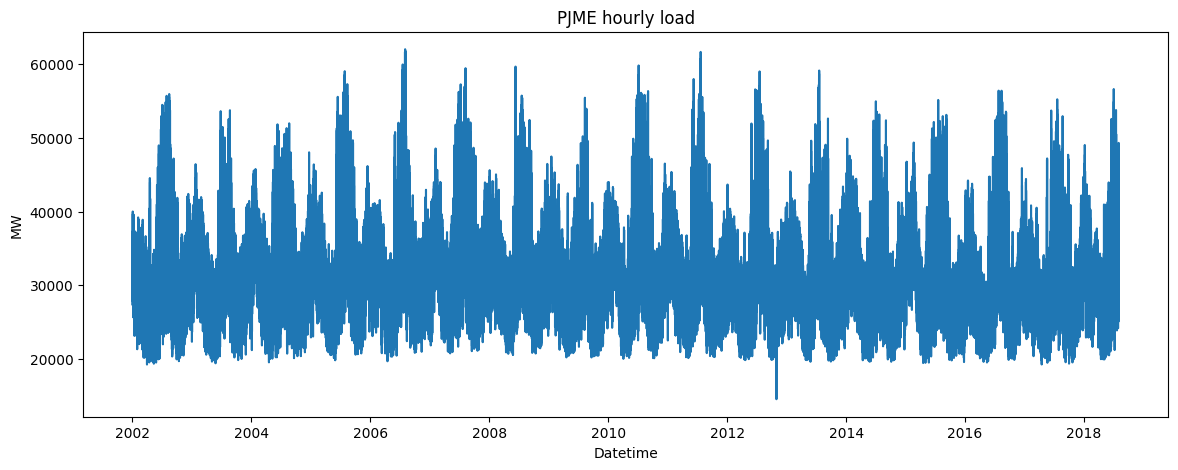

In [ ]:
plt.figure()
plt.plot(data["ds"], data["y"])
plt.title("PJME hourly load")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.show()

**Nhận xét :** Biểu đồ chuỗi thời gian cho thấy nhu cầu tiêu thụ điện PJME theo giờ từ năm 2002 đến 2018 có tính dao động mạnh và lặp lại theo chu kỳ rõ rệt. Mức tiêu thụ biến động trong khoảng khoảng 20.000 MW đến trên 60.000 MW, thể hiện tính mùa vụ và chu kỳ hàng năm khá rõ, phù hợp cho bài toán dự báo chuỗi thời gian.

##7. Chia tập Train và Test theo thời gian

In [ ]:
test_days = 180
cutoff = data["ds"].max() - pd.Timedelta(days=test_days)

train = data[data["ds"] <= cutoff].copy()
test  = data[data["ds"] >  cutoff].copy()

print("Train:", train.shape, "from", train["ds"].min(), "to", train["ds"].max())
print("Test :", test.shape,  "from", test["ds"].min(),  "to", test["ds"].max())

Train: (141072, 2) from 2002-01-01 01:00:00 to 2018-02-04 00:00:00
Test : (4320, 2) from 2018-02-04 01:00:00 to 2018-08-03 00:00:00


Dữ liệu được chia theo thời gian với 180 ngày cuối làm tập test.
- Tập train gồm 141.072 quan sát từ 2002 đến đầu năm 2018.
- Trong khi tập test gồm 4.320 quan sát trong 6 tháng cuối năm 2018.

Cách chia này đảm bảo tính đúng đắn của bài toán dự báo chuỗi thời gian, tránh rò rỉ dữ liệu tương lai.

##8. Huấn luyện Prophet

In [ ]:
m = Prophet(
    growth="linear",
    seasonality_mode="multiplicative",
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)

m.fit(train)

Mô hình Prophet được huấn luyện với xu hướng tuyến tính và tính mùa vụ nhân, đồng thời kích hoạt các chu kỳ ngày, tuần và năm để phù hợp với đặc trưng tiêu thụ điện theo giờ. Tham số changepoint_prior_scale = 0.05 giúp kiểm soát mức độ linh hoạt của xu hướng, hạn chế hiện tượng quá khớp dữ liệu.

##9. Dự báo trên tập Test và đánh giá (MAE, RMSE, MAPE)

In [ ]:
future_test = test[["ds"]].copy()
fc_test = m.predict(future_test)

eval_df = test.merge(fc_test[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds", how="left")

# Metrics
mae  = np.mean(np.abs(eval_df["y"] - eval_df["yhat"]))
rmse = np.sqrt(np.mean((eval_df["y"] - eval_df["yhat"])**2))
mape = np.mean(np.abs((eval_df["y"] - eval_df["yhat"]) / eval_df["y"])) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

eval_df.head()

MAE : 2978.051993138765
RMSE: 3871.8181522903733
MAPE: 9.47581657499934 %


,ds,y,yhat,yhat_lower,yhat_upper
0,2018-02-04 01:00:00,31049.0,25883.986044,21292.380681,30837.517536
1,2018-02-04 02:00:00,30100.0,24440.388721,20109.013172,28596.737535
2,2018-02-04 03:00:00,29521.0,23601.825487,19371.334310,28269.614257
3,2018-02-04 04:00:00,29255.0,23468.832241,18978.445948,28041.057608
4,2018-02-04 05:00:00,29297.0,24127.506037,19720.434072,29067.076554


Kết quả đánh giá trên tập test cho thấy mô hình Prophet:
- MAE khoảng 2.978 MW và RMSE khoảng 3.871 MW, phản ánh sai số trung bình ở mức chấp nhận được so với biên độ dao động lớn của phụ tải điện.
- Giá trị MAPE khoảng 9,48% cho thấy mô hình dự báo tương đối tốt, với sai lệch trung bình dưới 10%, phù hợp cho bài toán dự báo nhu cầu điện ngắn hạn.

###Vẽ so sánh Actual vs Forecast (Test)

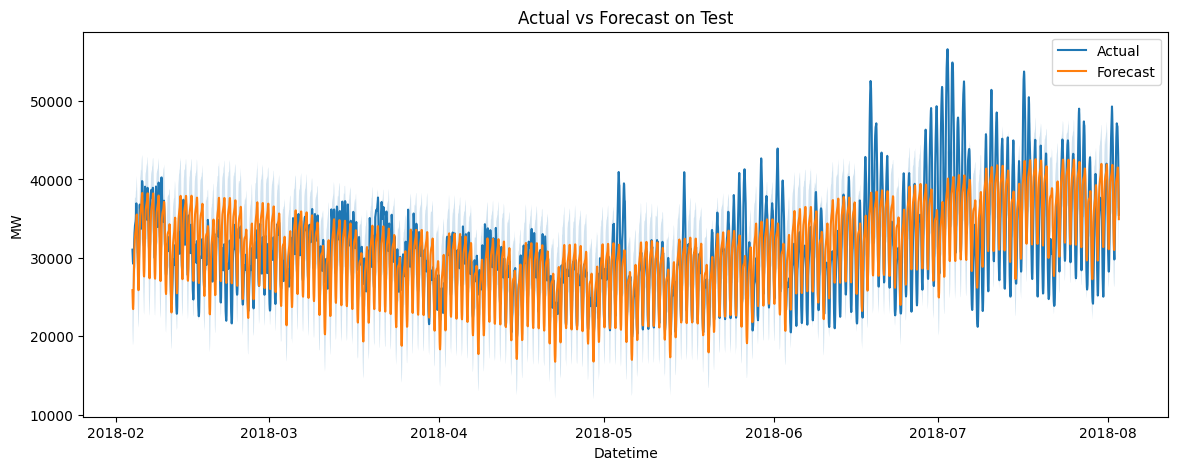

In [ ]:
plt.figure()
plt.plot(eval_df["ds"], eval_df["y"], label="Actual")
plt.plot(eval_df["ds"], eval_df["yhat"], label="Forecast")
plt.fill_between(eval_df["ds"], eval_df["yhat_lower"], eval_df["yhat_upper"], alpha=0.2)
plt.title("Actual vs Forecast on Test")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.legend()
plt.show()

**Nhận xét :** Biểu đồ so sánh cho thấy đường dự báo (Forecast) bám khá sát xu hướng thực tế (Actual), đặc biệt là tính chu kỳ theo giờ và xu hướng tăng dần vào giữa năm. Tuy nhiên, mô hình vẫn chưa bắt kịp các đỉnh cao đột biến trong giai đoạn mùa hè, dẫn đến sai lệch tại một số thời điểm phụ tải tăng mạnh.

###Huấn luyện mô hình trên tập train


In [ ]:
from prophet import Prophet

model = Prophet(
    seasonality_mode="multiplicative",
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(train)

###Dự đoán trên tập Test

In [ ]:
future_test = test[["ds"]].copy()

forecast_test = model.predict(future_test)

forecast_test.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,daily,daily_lower,daily_upper,multiplicative_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2018-02-04 01:00:00,30853.859247,21353.803482,30453.653002,30853.859247,30853.859247,-0.135621,-0.135621,-0.135621,-0.161078,...,-0.097149,-0.097149,-0.097149,0.071691,0.071691,0.071691,0.0,0.0,0.0,25883.986044
1,2018-02-04 02:00:00,30853.834277,20001.144202,29300.699021,30853.834277,30853.834277,-0.181338,-0.181338,-0.181338,-0.207865,...,-0.098108,-0.098108,-0.098108,0.071581,0.071581,0.071581,0.0,0.0,0.0,24440.388721
2,2018-02-04 03:00:00,30853.809307,19082.935010,28251.723201,30853.809307,30853.809307,-0.207813,-0.207813,-0.207813,-0.235043,...,-0.098702,-0.098702,-0.098702,0.071471,0.071471,0.071471,0.0,0.0,0.0,23601.825487
3,2018-02-04 04:00:00,30853.784337,18675.818160,28111.906261,30853.784337,30853.784337,-0.211792,-0.211792,-0.211792,-0.239353,...,-0.098922,-0.098922,-0.098922,0.071361,0.071361,0.071361,0.0,0.0,0.0,23468.832241
4,2018-02-04 05:00:00,30853.759367,19248.402961,28462.912730,30853.759367,30853.759367,-0.190489,-0.190489,-0.190489,-0.218004,...,-0.098767,-0.098767,-0.098767,0.071252,0.071252,0.071252,0.0,0.0,0.0,24127.506037


###Ghép dự báo với dữ liệu thực tế

In [ ]:
eval_df = test.merge(
    forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="left"
)

eval_df.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2018-02-04 01:00:00,31049.0,25883.986044,21353.803482,30453.653002
1,2018-02-04 02:00:00,30100.0,24440.388721,20001.144202,29300.699021
2,2018-02-04 03:00:00,29521.0,23601.825487,19082.935010,28251.723201
3,2018-02-04 04:00:00,29255.0,23468.832241,18675.818160,28111.906261
4,2018-02-04 05:00:00,29297.0,24127.506037,19248.402961,28462.912730


###Tính sai số

In [ ]:
import numpy as np

mae  = np.mean(np.abs(eval_df["y"] - eval_df["yhat"]))
rmse = np.sqrt(np.mean((eval_df["y"] - eval_df["yhat"])**2))
mape = np.mean(np.abs((eval_df["y"] - eval_df["yhat"]) / eval_df["y"])) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE : 2978.051993138765
RMSE: 3871.8181522903733
MAPE: 9.47581657499934 %


###Vẽ biểu đồ So sánh Thực tế vs Dự báo

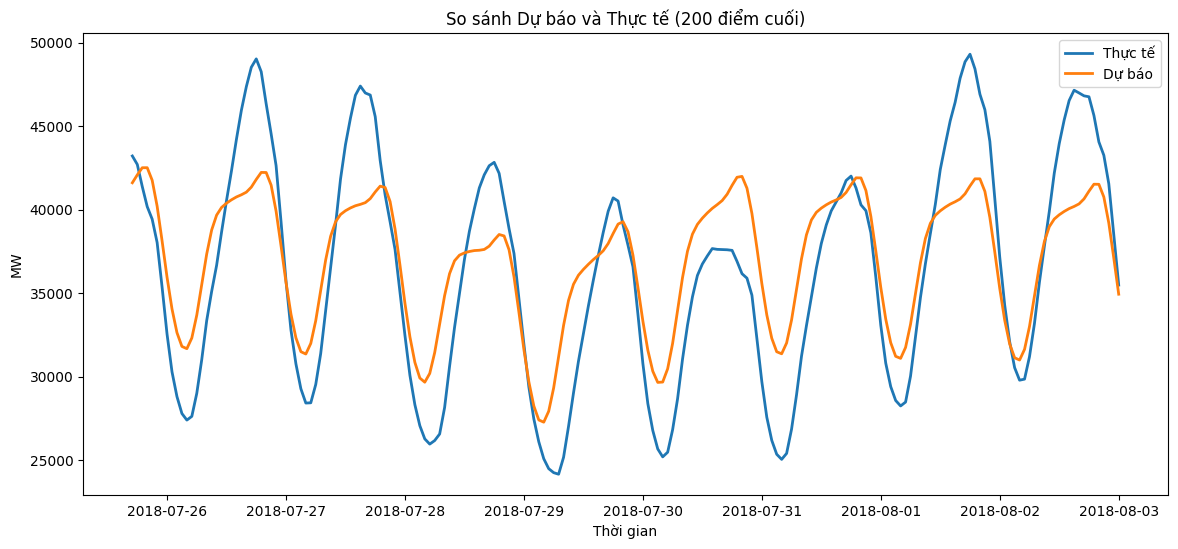

In [ ]:
last_200 = eval_df.tail(200)

plt.figure(figsize=(14,6))

plt.plot(last_200["ds"], last_200["y"], label="Thực tế", linewidth=2)
plt.plot(last_200["ds"], last_200["yhat"], label="Dự báo", linewidth=2)

plt.title("So sánh Dự báo và Thực tế (200 điểm cuối)")
plt.xlabel("Thời gian")
plt.ylabel("MW")
plt.legend()
plt.show()

##10. Vẽ Forecast toàn bộ và phân rã thành phần (Components)

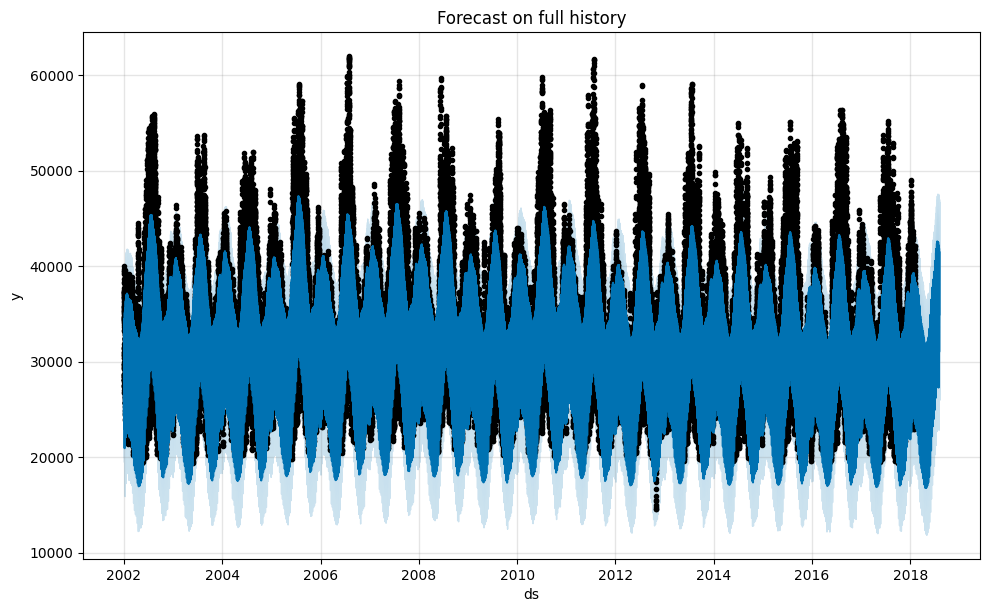

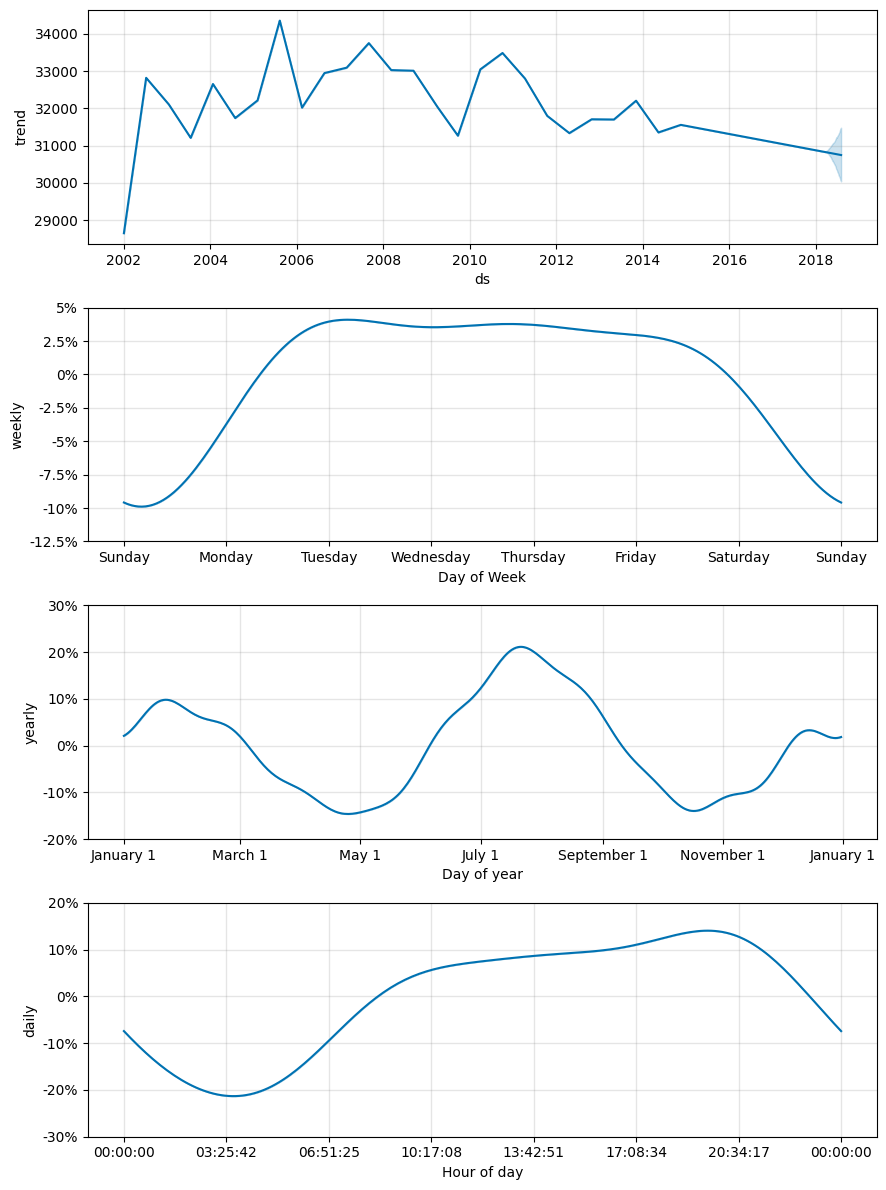

In [ ]:
fc_all = m.predict(data[["ds"]])

fig1 = m.plot(fc_all)
plt.title("Forecast on full history")
plt.show()

fig2 = m.plot_components(fc_all)
plt.show()

Biểu đồ dự báo trên toàn bộ lịch sử cho thấy mô hình Prophet bám sát xu hướng chung của phụ tải điện và tái hiện khá rõ các dao động chu kỳ.

 Thành phần **trend** thể hiện xu hướng biến động theo từng giai đoạn, có sự tăng trưởng đến khoảng 2006–2008 và sau đó dao động nhẹ.

 Thành phần **weekly** cho thấy phụ tải cao hơn vào giữa tuần và giảm mạnh vào cuối tuần, đặc biệt là Chủ nhật.

 Thành phần **yearly** phản ánh tính mùa vụ rõ rệt, với mức tiêu thụ cao vào mùa hè và thấp vào mùa xuân, thu.

 Thành phần **daily** cho thấy phụ tải thấp vào rạng sáng và tăng mạnh vào buổi chiều tối. Điều này phù hợp với đặc trưng tiêu thụ điện trong thực tế.

##11. Thử thêm seasonality tuỳ chỉnh theo giờ (giúp mô hình linh hoạt hơn)

In [ ]:
m2 = Prophet(
    seasonality_mode="multiplicative",
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05
)

# Add seasonality custom
m2.add_seasonality(name="daily", period=1, fourier_order=15)     # 1 ngày
m2.add_seasonality(name="weekly", period=7, fourier_order=10)    # 7 ngày

m2.fit(train)

fc_test2 = m2.predict(test[["ds"]])
eval2 = test.merge(fc_test2[["ds","yhat"]], on="ds")

mae2  = np.mean(np.abs(eval2["y"] - eval2["yhat"]))
rmse2 = np.sqrt(np.mean((eval2["y"] - eval2["yhat"])**2))
mape2 = np.mean(np.abs((eval2["y"] - eval2["yhat"]) / eval2["y"])) * 100

print("Model 2 MAE :", mae2)
print("Model 2 RMSE:", rmse2)
print("Model 2 MAPE:", mape2, "%")

Model 2 MAE : 2929.312177860251
Model 2 RMSE: 3827.4383066736327
Model 2 MAPE: 9.277473174698999 %


##12. Cross Validation chuẩn của Prophet

INFO:prophet:Making 13 forecasts with cutoffs between 2012-02-06 00:00:00 and 2018-01-05 00:00:00


  0%|          | 0/13 [00:00<?, ?it/s]

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,3 days 00:00:00,3.394977e+07,5826.643173,4579.573414,0.124239,0.103233,0.127065,0.583333
1,3 days 01:00:00,3.387871e+07,5820.541718,4573.158026,0.124046,0.102806,0.126887,0.583333
2,3 days 02:00:00,3.381547e+07,5815.107430,4568.321547,0.123886,0.102484,0.126742,0.583333
3,3 days 03:00:00,3.375857e+07,5810.212757,4565.398142,0.123774,0.103233,0.126648,0.582265
4,3 days 04:00:00,3.370614e+07,5805.698734,4564.541212,0.123716,0.104123,0.126609,0.581197


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


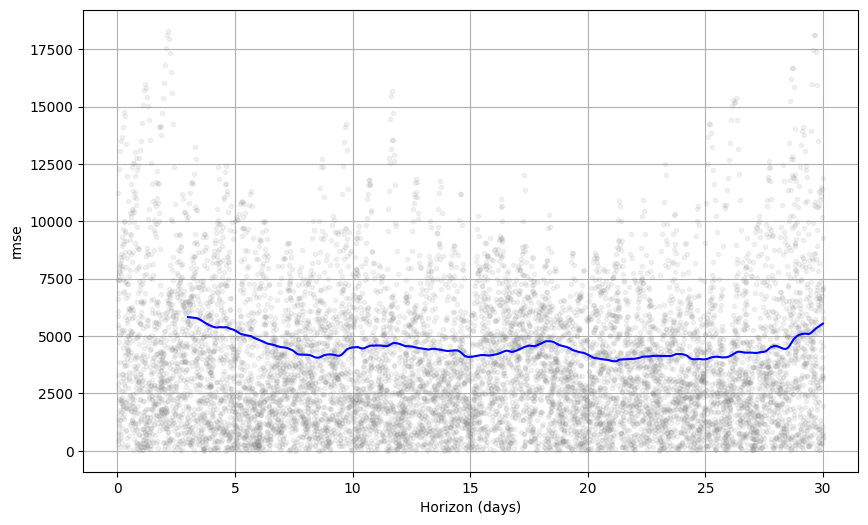

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


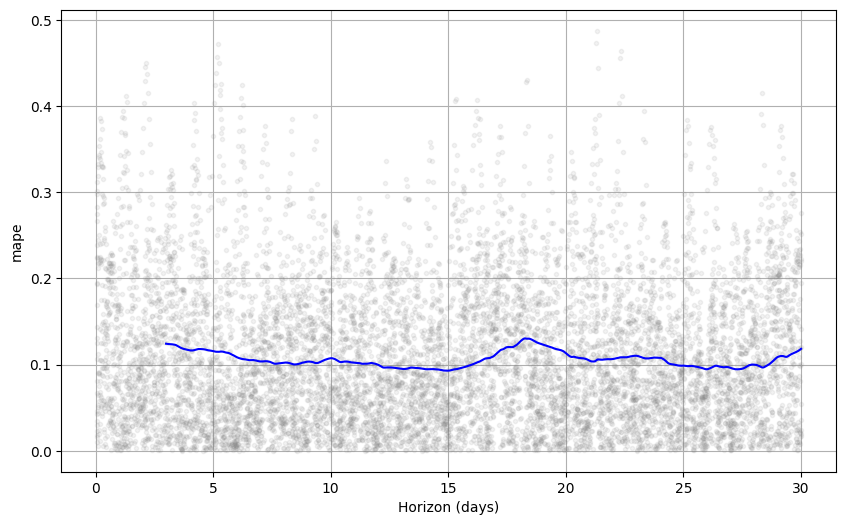

In [ ]:
df_cv = cross_validation(
    m,
    initial="3650 days",
    period="180 days",
    horizon="30 days"
)

df_p = performance_metrics(df_cv)
display(df_p.head())

plot_cross_validation_metric(df_cv, metric="rmse")
plt.show()

plot_cross_validation_metric(df_cv, metric="mape")
plt.show()

##13. Dự báo tương lai

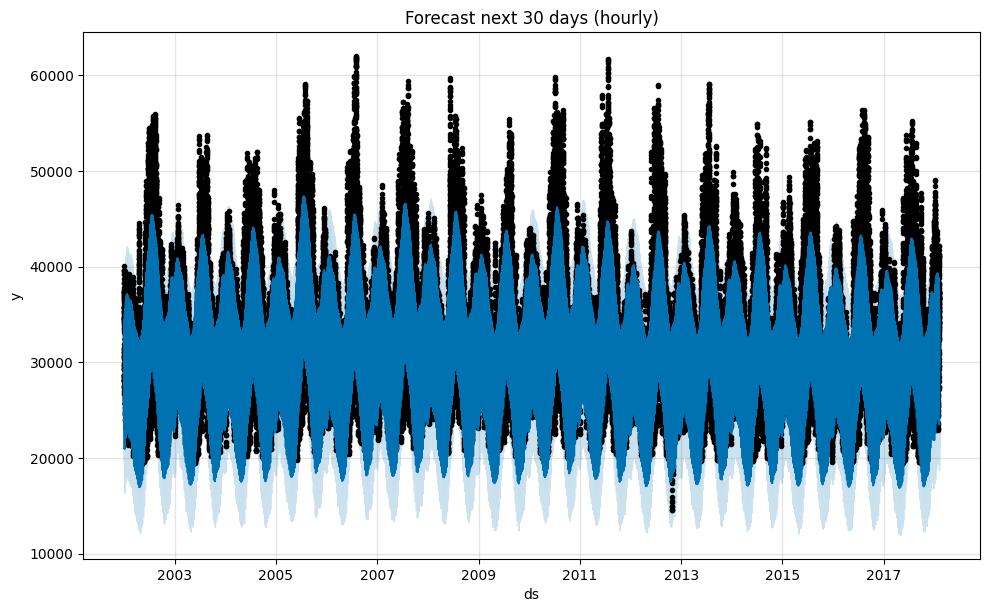

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,daily,daily_lower,daily_upper,multiplicative_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
141091,2018-02-04 20:00:00,30853.384815,31040.781106,40015.168473,30853.384815,30853.384815,0.138142,0.138142,0.138142,0.151461,...,-0.056323,-0.056323,-0.056323,0.069642,0.069642,0.069642,0.0,0.0,0.0,35526.478339
141092,2018-02-04 21:00:00,30853.359845,30100.675199,39642.209115,30853.359845,30853.359845,0.113909,0.113909,0.113909,0.131837,...,-0.051609,-0.051609,-0.051609,0.069537,0.069537,0.069537,0.0,0.0,0.0,34920.985078
141093,2018-02-04 22:00:00,30853.334875,29093.295478,37942.401813,30853.334875,30853.334875,0.063670,0.063670,0.063670,0.086302,...,-0.046800,-0.046800,-0.046800,0.069432,0.069432,0.069432,0.0,0.0,0.0,33516.050698
141094,2018-02-04 23:00:00,30853.309905,27100.025314,36100.129770,30853.309905,30853.309905,-0.003690,-0.003690,-0.003690,0.023715,...,-0.041923,-0.041923,-0.041923,0.069328,0.069328,0.069328,0.0,0.0,0.0,31585.001881
141095,2018-02-05 00:00:00,30853.284935,25357.412759,34329.267551,30853.284935,30853.284935,-0.074134,-0.074134,-0.074134,-0.041918,...,-0.037008,-0.037008,-0.037008,0.069224,0.069224,0.069224,0.0,0.0,0.0,29559.983473


In [ ]:
hours = 1 * 24
future = m.make_future_dataframe(periods=hours, freq="h")
forecast_future = m.predict(future)

fig = m.plot(forecast_future)
plt.title("Forecast next 30 days (hourly)")
plt.show()

forecast_future.tail()

In [ ]:
model = Prophet(
    seasonality_mode="multiplicative",
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(data)

In [ ]:
future = model.make_future_dataframe(periods=24, freq="h")

In [ ]:
forecast = model.predict(future)

In [ ]:
forecast_24h = forecast.tail(24)[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

forecast_24h

,ds,yhat,yhat_lower,yhat_upper
145392,2018-08-03 01:00:00,33017.164038,28405.849889,37667.314496
145393,2018-08-03 02:00:00,31597.060065,26473.541578,35680.193823
145394,2018-08-03 03:00:00,30766.673141,26165.182736,35486.862757
145395,2018-08-03 04:00:00,30625.484478,26086.390061,35115.131304
145396,2018-08-03 05:00:00,31258.582780,26542.963000,35886.371552
145397,2018-08-03 06:00:00,32617.658884,27851.679825,37211.203779
145398,2018-08-03 07:00:00,34424.772618,30000.652336,39155.892248
145399,2018-08-03 08:00:00,36235.474323,31538.906134,40822.525034
145400,2018-08-03 09:00:00,37650.753004,32936.374946,42239.989264
145401,2018-08-03 10:00:00,38516.546596,34238.726640,43351.356399


###Dự báo 24h tiếp theo


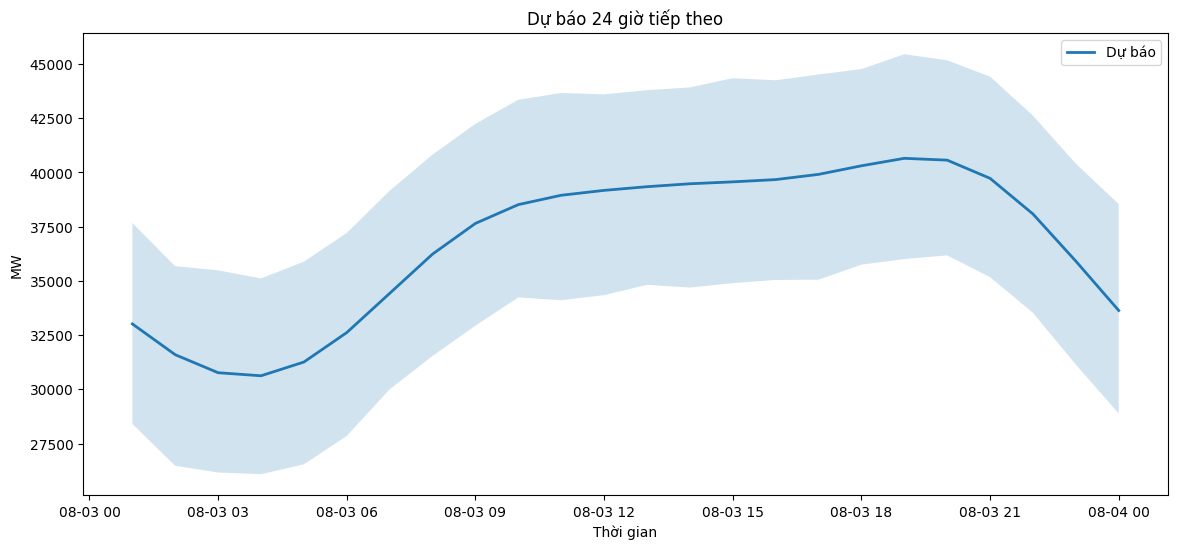

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(forecast_24h["ds"], forecast_24h["yhat"], label="Dự báo", linewidth=2)

plt.fill_between(
    forecast_24h["ds"],
    forecast_24h["yhat_lower"],
    forecast_24h["yhat_upper"],
    alpha=0.2
)

plt.title("Dự báo 24 giờ tiếp theo")
plt.xlabel("Thời gian")
plt.ylabel("MW")
plt.legend()
plt.show()